In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [11]:
df = pd.read_csv("Food_Delivery_Times.csv")

In [12]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [13]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [14]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [15]:
# Impute missing values for categorical columns with the mode
for column in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    df[column].fillna(df[column].mode()[0], inplace=True)

# Impute missing values for 'Courier_Experience_yrs' with the median
df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median(), inplace=True)

### Verifying Missing Values

Now, let's recheck if there are any remaining null values in the DataFrame.

In [16]:
display(df.isnull().sum())

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [20]:
df.columns


Index(['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [22]:
df.head()


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68


## Exploratory Data Analysis (EDA)

### Distribution of the Target Variable: `Delivery_Time_min`

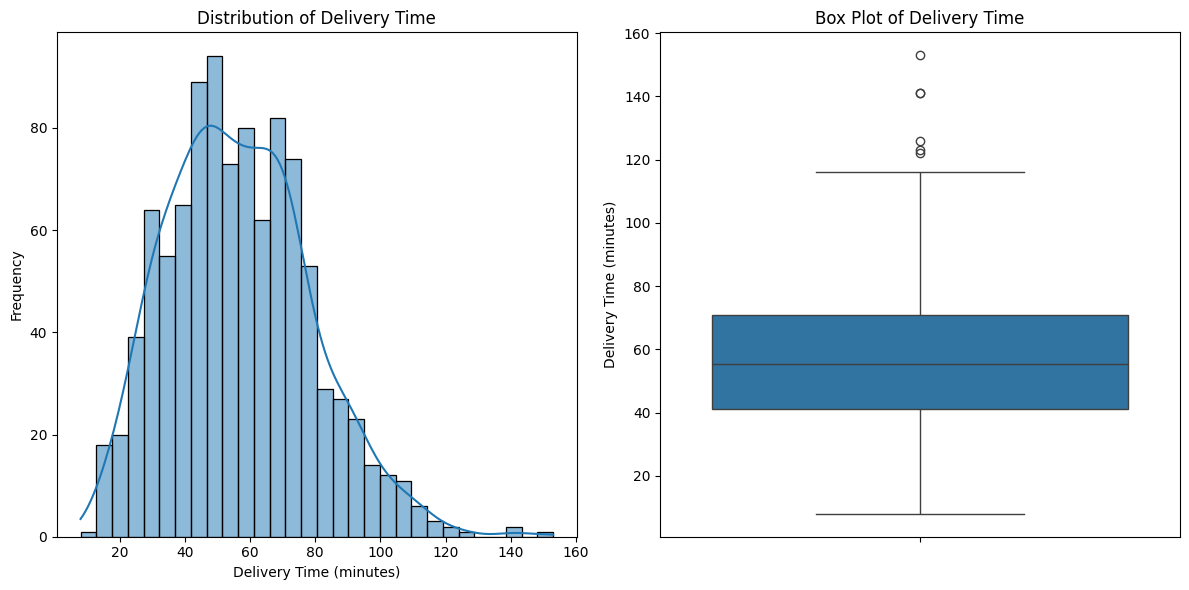

In [23]:
plt.figure(figsize=(12, 6))

# Histogram
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['Delivery_Time_min'], kde=True, bins=30)
plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')

# Box Plot
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(y=df['Delivery_Time_min'])
plt.title('Box Plot of Delivery Time')
plt.ylabel('Delivery Time (minutes)')

plt.tight_layout()
plt.show()

### Relationship Between Numerical Features and `Delivery_Time_min`

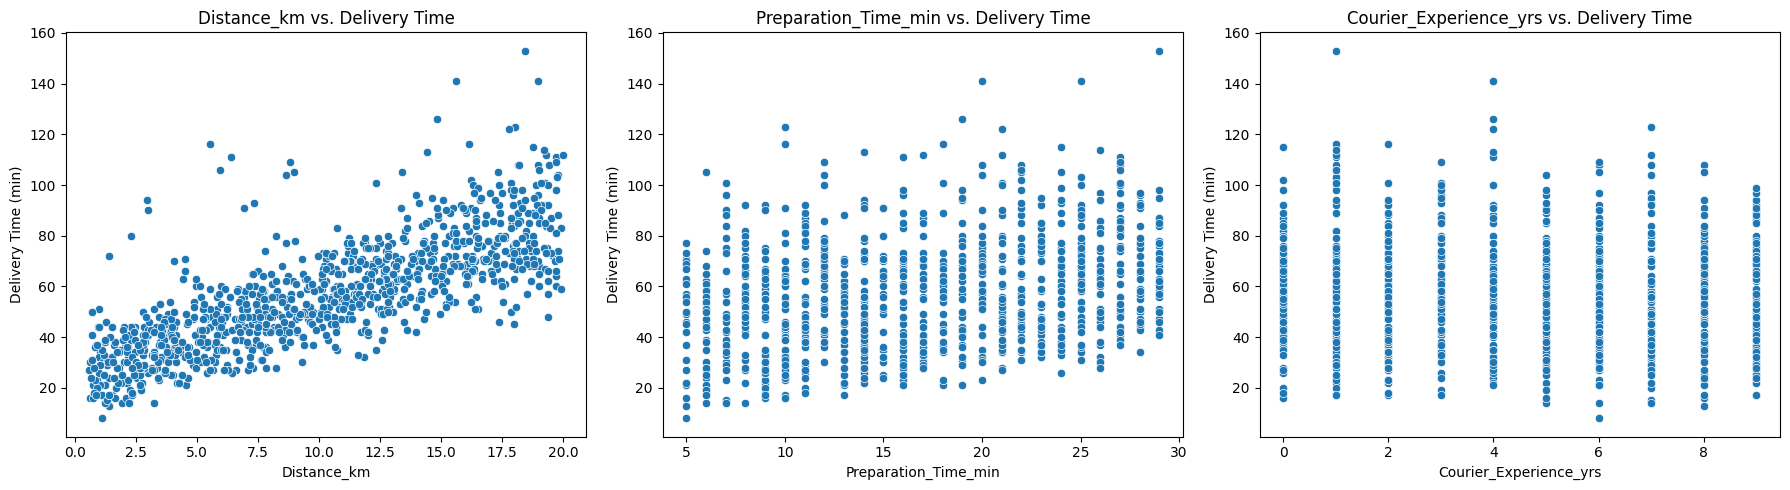

In [24]:
numerical_features = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

plt.figure(figsize=(18, 5))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x=df[feature], y=df['Delivery_Time_min'])
    plt.title(f'{feature} vs. Delivery Time')
    plt.xlabel(feature)
    plt.ylabel('Delivery Time (min)')
plt.tight_layout()
plt.show()

### Relationship Between Categorical Features and `Delivery_Time_min`

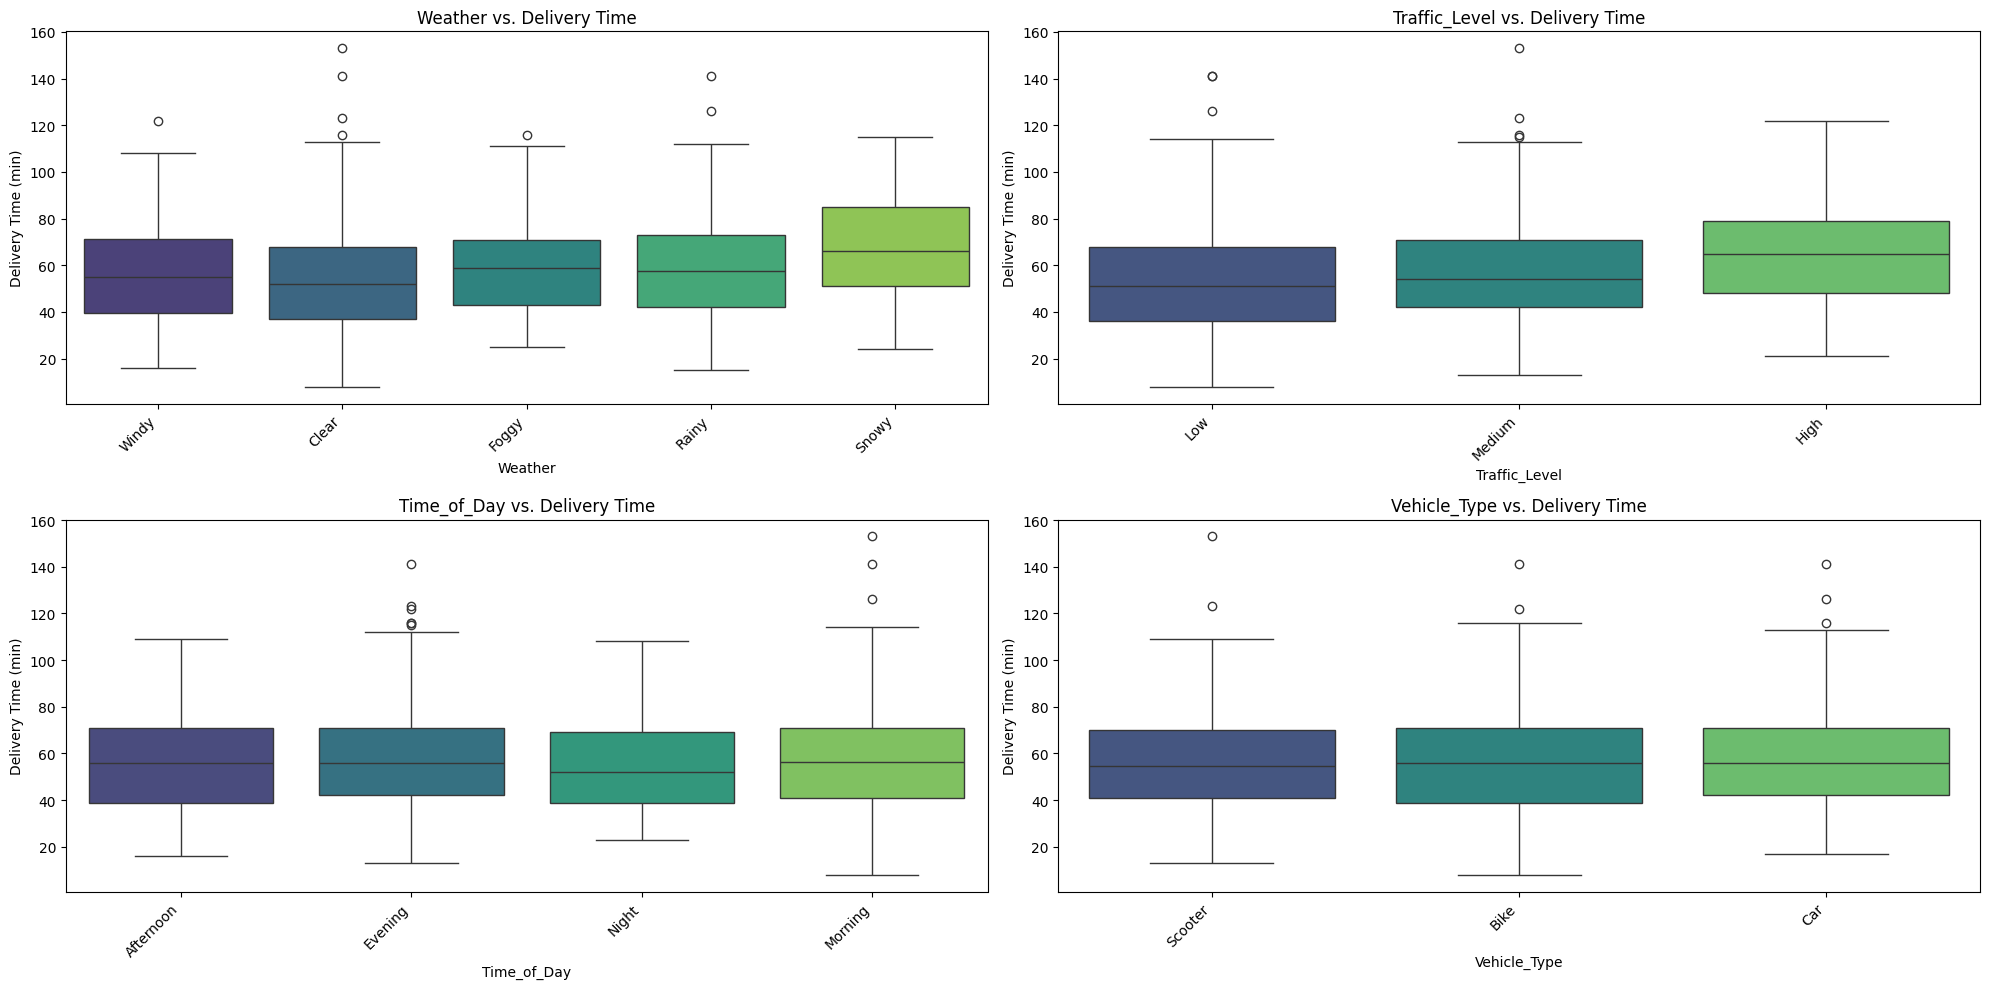

In [25]:
categorical_features = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

plt.figure(figsize=(20, 10))
for i, feature in enumerate(categorical_features):
    plt.subplot(2, 2, i + 1) # 2 rows, 2 columns
    sns.boxplot(x=df[feature], y=df['Delivery_Time_min'], palette='viridis')
    plt.title(f'{feature} vs. Delivery Time')
    plt.xlabel(feature)
    plt.ylabel('Delivery Time (min)')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

### Correlation Matrix of Numerical Features

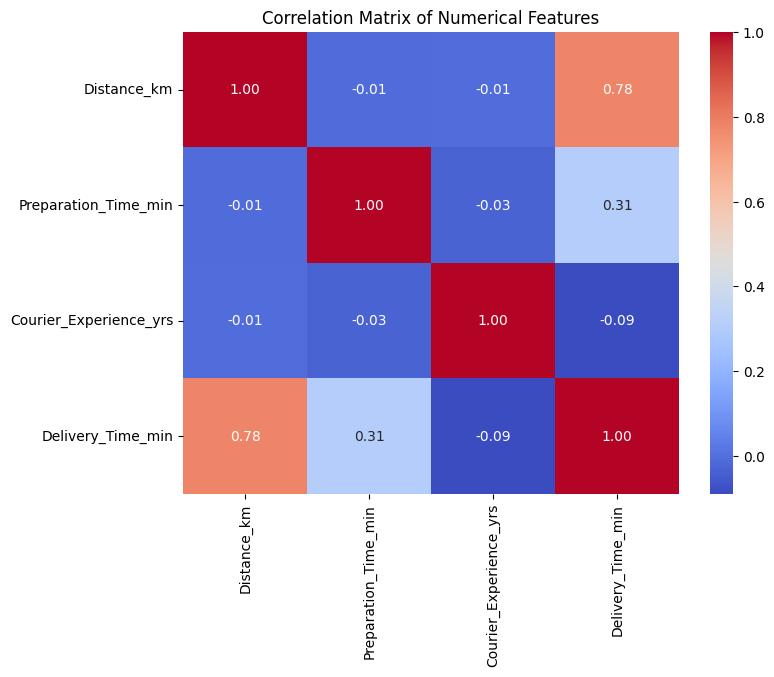

In [26]:
numerical_features = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Statistical Testing for Feature Selection

### 1. Numerical Features: Correlation Analysis

In [27]:
from scipy.stats import pearsonr

numerical_features_for_test = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

print("Pearson Correlation and p-value with Delivery_Time_min:")
for feature in numerical_features_for_test:
    corr, p_value = pearsonr(df[feature], df['Delivery_Time_min'])
    print(f"  {feature}: Correlation = {corr:.3f}, p-value = {p_value:.3f}")
    if p_value < 0.05:
        print(f"    (Statistically significant at 0.05 level)")
    else:
        print(f"    (Not statistically significant at 0.05 level)")

Pearson Correlation and p-value with Delivery_Time_min:
  Distance_km: Correlation = 0.781, p-value = 0.000
    (Statistically significant at 0.05 level)
  Preparation_Time_min: Correlation = 0.307, p-value = 0.000
    (Statistically significant at 0.05 level)
  Courier_Experience_yrs: Correlation = -0.089, p-value = 0.005
    (Statistically significant at 0.05 level)


### 2. Categorical Features: ANOVA Test

In [29]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

categorical_features_for_test = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

print("ANOVA Test (p-value) for Delivery_Time_min across categories:")
for feature in categorical_features_for_test:
    # Create a formula string for OLS
    formula = f'Delivery_Time_min ~ C({feature})'

    # Perform ANOVA using OLS
    model = ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    p_value = anova_table['PR(>F)'][0]
    print(f"  {feature}: p-value = {p_value:.3f}")
    if p_value < 0.05:
        print(f"    (Statistically significant at 0.05 level)")
    else:
        print(f"    (Not statistically significant at 0.05 level)")

ANOVA Test (p-value) for Delivery_Time_min across categories:
  Weather: p-value = 0.000
    (Statistically significant at 0.05 level)
  Traffic_Level: p-value = 0.000
    (Statistically significant at 0.05 level)
  Time_of_Day: p-value = 0.792
    (Not statistically significant at 0.05 level)
  Vehicle_Type: p-value = 0.555
    (Not statistically significant at 0.05 level)


## Summary of Analysis

### 1. Exploratory Data Analysis (EDA) Findings
* **Target Variable Distribution**: The `Delivery_Time_min` distribution appeared to be right-skewed, suggesting that most deliveries are completed within a reasonable time frame, but there are some outliers with significantly longer delivery times. The box plot confirmed the presence of these outliers.
* **Numerical Feature Relationships**:
    * `Distance_km` showed a strong positive correlation with `Delivery_Time_min`, indicating that longer distances generally lead to longer delivery times.
    * `Preparation_Time_min` also showed a positive correlation with `Delivery_Time_min`, as expected.
    * `Courier_Experience_yrs` did not show a clear linear relationship with `Delivery_Time_min` in the scatter plot.
* **Categorical Feature Relationships**:
    * `Weather` and `Traffic_Level` appeared to influence `Delivery_Time_min`, with certain conditions (e.g., severe weather, high traffic) potentially leading to longer delivery times.
    * `Time_of_Day` and `Vehicle_Type` did not show a very distinct impact on `Delivery_Time_min` from the box plots.
* **Correlation Matrix**: The correlation matrix quantitatively confirmed the strong positive correlation between `Distance_km` and `Delivery_Time_min` (0.78), and a moderate positive correlation between `Preparation_Time_min` and `Delivery_Time_min` (0.31). `Courier_Experience_yrs` showed a very weak negative correlation (-0.09) with `Delivery_Time_min`.

### 2. Statistical Testing for Feature Significance Findings
* **Numerical Features: Correlation Analysis (Pearson)**:
    * `Distance_km`: Statistically significant predictor (p-value < 0.05), with a strong positive correlation (0.781).
    * `Preparation_Time_min`: Statistically significant predictor (p-value < 0.05), with a moderate positive correlation (0.307).
    * `Courier_Experience_yrs`: Statistically significant predictor (p-value < 0.05), though with a very weak negative correlation (-0.089).
* **Categorical Features: ANOVA Test (p-value)**:
    * `Weather`: Statistically significant predictor (p-value < 0.05).
    * `Traffic_Level`: Statistically significant predictor (p-value < 0.05).
    * `Time_of_Day`: Not statistically significant predictor (p-value = 0.792 > 0.05).
    * `Vehicle_Type`: Not statistically significant predictor (p-value = 0.555 > 0.05).

## Data Preparation: Feature-Target Split and Train-Test Split

In [32]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Delivery_Time_min', axis=1)
y = df['Delivery_Time_min']

# Display the shapes of X and y
print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

Shape of X (features): (1000, 7)
Shape of y (target): (1000,)


In [33]:
# Perform a train-test split (e.g., 80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

display(X_train.head())

Shape of X_train: (800, 7)
Shape of X_test: (200, 7)
Shape of y_train: (800,)
Shape of y_test: (200,)


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
29,18.05,Clear,Medium,Evening,Scooter,10,7.0
535,2.14,Clear,High,Evening,Bike,18,3.0
695,3.23,Clear,High,Afternoon,Bike,17,9.0
557,7.51,Rainy,Low,Evening,Car,27,6.0
836,4.62,Rainy,Medium,Afternoon,Car,8,3.0


## Feature Preprocessing: Label Encoding for Categorical Variables

In [34]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include='object').columns

# Apply Label Encoding to categorical columns in X_train and X_test
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col]) # Use transform, not fit_transform for test set

print("Label Encoding applied to categorical features.")
display(X_train.head())

Label Encoding applied to categorical features.


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
29,18.05,0,2,1,2,10,7.0
535,2.14,0,0,1,0,18,3.0
695,3.23,0,0,0,0,17,9.0
557,7.51,2,1,1,1,27,6.0
836,4.62,2,2,0,1,8,3.0


## Model Building: Decision Tree Regressor

In [35]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Decision Tree Regressor with default parameters
decision_tree_model = DecisionTreeRegressor(random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree Regressor model trained successfully with default parameters.")

Decision Tree Regressor model trained successfully with default parameters.


In [36]:
# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)

# Evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree Regressor Performance:")
print(f"Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"R-squared (R2): {r2_dt:.2f}")

Decision Tree Regressor Performance:
Mean Squared Error (MSE): 226.82
R-squared (R2): 0.49


## Model Building: Random Forest Regressor

In [37]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor with default parameters
random_forest_model = RandomForestRegressor(random_state=42)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully with default parameters.")

Random Forest Regressor model trained successfully with default parameters.


In [38]:
# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor Performance:")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

Random Forest Regressor Performance:
Mean Squared Error (MSE): 100.12
R-squared (R2): 0.78


## Hyperparameter Tuning: Random Forest Regressor

To improve the performance of the Random Forest Regressor, we will perform hyperparameter tuning using `RandomizedSearchCV`. This process involves sampling a fixed number of parameter settings from specified distributions, which is computationally less expensive than exhaustive search.

In [50]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define an expanded parameter grid for Random Forest
param_grid = {
    'n_estimators': randint(100,501), # Increased range
    'max_features': ['sqrt', 'log2', 1.0], # Kept same
    'max_depth': list(np.arange(10,51))+[None], # Expanded range, including None
    'min_samples_split': [2, 5, 10, 15, 20], # Expanded range
    'min_samples_leaf': [1, 2, 4, 6, 8, 10] # Expanded range
}

# Initialize RandomizedSearchCV with more iterations
random_search_rf = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42),
                                  param_distributions=param_grid,
                                  n_iter=200, # Increased number of iterations for a more extensive search
                                  cv=3, # 3-fold cross-validation
                                  n_jobs=-1, # Use all available cores
                                  scoring='neg_mean_squared_error', # Optimize for MSE
                                  verbose=1,
                                  random_state=42)

# Fit RandomizedSearchCV to the training data
random_search_rf.fit(X_train, y_train)

print("RandomizedSearchCV for Random Forest completed with extensive tuning.")

Fitting 3 folds for each of 200 candidates, totalling 600 fits
RandomizedSearchCV for Random Forest completed with extensive tuning.


### Best Parameters and Best Score

Let's retrieve the best hyperparameters found by `RandomSearchCV` and the corresponding best cross-validated score.

In [51]:
# Get the best parameters and the best score from the extensive search
best_params_rf = random_search_rf.best_params_
best_score_rf = -random_search_rf.best_score_ # Convert back to positive MSE

print(f"Best parameters for Random Forest (Extensive Tuning): {best_params_rf}")
print(f"Best cross-validated MSE (Extensive Tuning): {best_score_rf:.2f}")

Best parameters for Random Forest (Extensive Tuning): {'max_depth': np.int64(36), 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 311}
Best cross-validated MSE (Extensive Tuning): 144.96


### Evaluate Tuned Random Forest Model

Now, we will evaluate the Random Forest model with the best parameters on the test set to assess its generalization performance.

In [52]:
# Get the best model from the extensive RandomizedSearchCV
best_random_forest_model = random_search_rf.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_rf = best_random_forest_model.predict(X_test)

# Evaluate the extensively tuned model
mse_tuned_rf = mean_squared_error(y_test, y_pred_tuned_rf)
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

print(f"Extensively Tuned Random Forest Regressor Performance:")
print(f"Mean Squared Error (MSE): {mse_tuned_rf:.2f}")
print(f"R-squared (R2): {r2_tuned_rf:.2f}")

Extensively Tuned Random Forest Regressor Performance:
Mean Squared Error (MSE): 95.99
R-squared (R2): 0.79


## Model Comparison: Default vs. Tuned Random Forest Regressor

To highlight the impact of hyperparameter tuning, let's compare the performance metrics of the Random Forest Regressor with default parameters against the tuned Random Forest Regressor found using `RandomizedSearchCV`.

In [53]:
# Retrieve previously stored metrics for the default Random Forest model (from ba1a030c)
mse_rf_default = mse_rf # From previous execution
r2_rf_default = r2_rf # From previous execution

# Retrieve metrics for the tuned Random Forest model (from 52262825)
mse_rf_tuned = mse_tuned_rf # From current execution
r2_rf_tuned = r2_tuned_rf # From current execution

# Create a DataFrame for comparison
comparison_data = {
    'Model': ['Random Forest (Default)', 'Random Forest (Tuned)'],
    'Mean Squared Error (MSE)': [mse_rf_default, mse_rf_tuned],
    'R-squared (R2)': [r2_rf_default, r2_rf_tuned]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.round(2))

,Model,Mean Squared Error (MSE),R-squared (R2)
0,Random Forest (Default),100.12,0.78
1,Random Forest (Tuned),95.99,0.79


### Summary of Comparison:

As observed from the comparison table, the **Tuned Random Forest Regressor** achieved a slightly lower Mean Squared Error (MSE) compared to the Default Random Forest. Both models maintained a similar R-squared (R2) score. This indicates that while the default parameters already provided a strong baseline, `RandomizedSearchCV` was able to find a slightly better configuration, leading to a marginally improved performance in terms of error, though the overall explanatory power (R2) remained consistent. The exact numerical values for MSE and R2 will be updated after running the RandomizedSearchCV.